# Deadlock Match Data — Exploratory Analysis

Working with `collected_matches_sample.jsonl` (1000 matches) plus lookup tables for hero/item names.

In [20]:
import json
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 40)

## Load lookup tables

In [21]:
items_lookup = pd.read_parquet('data/public_items.parquet')
heroes_lookup = pd.read_parquet('data/public_heroes.parquet')

# Decode bytes columns if needed
for col in items_lookup.select_dtypes(include='object').columns:
    items_lookup[col] = items_lookup[col].apply(
        lambda x: x.decode() if isinstance(x, bytes) else x
    )

print('items_lookup shape:', items_lookup.shape)
display(items_lookup.head(5))

print('heroes_lookup shape:', heroes_lookup.shape)
display(heroes_lookup.head(5))

items_lookup shape: (455, 6)


/tmp/ipykernel_5298/2239931464.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in items_lookup.select_dtypes(include='object').columns:


,id,name,tier,type,slot_type,cost
0,6698938,tokamak_heat_sinks,NaN,ability,NaN,NaN
1,7409189,Improved Spirit,2.0,upgrade,spirit,1600.0
2,11154161,Hex-Lined Snap Trap,NaN,ability,NaN,NaN
3,12456023,Spectral Assistant,NaN,ability,NaN,NaN
4,18921423,Frost Grenade,NaN,ability,NaN,NaN


heroes_lookup shape: (38, 2)


,id,name
0,1,Infernus
1,2,Seven
2,3,Vindicta
3,4,Lady Geist
4,6,Abrams


In [22]:
# Only real purchasable items (type == 'upgrade'); exclude ability entries
upgrade_items = items_lookup[items_lookup['type'] == 'upgrade'].copy()
print(f'{len(upgrade_items)} purchasable upgrade items')
display(upgrade_items.head(10))

171 purchasable upgrade items


,id,name,tier,type,slot_type,cost
1,7409189,Improved Spirit,2.0,upgrade,spirit,1600.0
6,26002154,Melee Charge,2.0,upgrade,weapon,1600.0
8,64550694,Runed Gauntlets,5.0,upgrade,weapon,9999.0
9,84321454,Quicksilver Reload,2.0,upgrade,spirit,1600.0
10,98582110,Stalker,2.0,upgrade,weapon,1600.0
14,112198670,Spirit Shielding,2.0,upgrade,vitality,1600.0
23,230297145,Eternal Gift,5.0,upgrade,vitality,9999.0
26,334300056,Stamina Mastery,3.0,upgrade,vitality,3200.0
27,339443430,Frenzy,4.0,upgrade,weapon,6400.0
28,343572757,Spirit Burn,4.0,upgrade,spirit,6400.0


In [23]:
# Build fast id->name dicts
item_id_to_name = items_lookup.set_index('id')['name'].to_dict()
hero_id_to_name = heroes_lookup.set_index('id')['name'].to_dict()
upgrade_item_ids = set(upgrade_items['id'])

## Load match data

In [24]:
with open('data/collected_matches_sample.jsonl') as f:
    raw_matches = [json.loads(line) for line in f]

print(f'Loaded {len(raw_matches)} matches')
print('Top-level keys:', list(raw_matches[0].keys()))

Loaded 1000 matches
Top-level keys: ['average_badge_team0', 'average_badge_team1', 'banned_hero_ids', 'duration_s', 'game_mode', 'match_id', 'match_mode', 'match_outcome', 'not_scored', 'players', 'start_time', 'winning_team']


## Flatten to player-level DataFrame

One row per (match, player). Hero presence per team can be queried directly from this.

In [25]:
player_rows = []
for match in raw_matches:
    match_id     = match['match_id']
    winning_team = match['winning_team']
    duration_s   = match['duration_s']
    start_time   = match['start_time']

    for p in match['players']:
        player_rows.append({
            'match_id':     match_id,
            'start_time':   start_time,
            'duration_s':   duration_s,
            'winning_team': winning_team,
            'team':         p['team'],
            'player_slot':  p['player_slot'],
            'hero_id':      p['hero_id'],
            'kills':        p['kills'],
            'deaths':       p['deaths'],
            'assists':      p['assists'],
            'net_worth':    p['net_worth'],
            'player_level': p['player_level'],
            'last_hits':    p['last_hits'],
        })

players_df = pd.DataFrame(player_rows)
players_df['won'] = players_df['team'] == players_df['winning_team']
players_df['hero_name'] = players_df['hero_id'].map(hero_id_to_name)
players_df['start_time'] = pd.to_datetime(players_df['start_time'])

print('players_df shape:', players_df.shape)
display(players_df.head(6))

players_df shape: (12000, 15)


,match_id,start_time,duration_s,winning_team,team,player_slot,hero_id,kills,deaths,assists,net_worth,player_level,last_hits,won,hero_name
0,38408619,2025-08-01 10:00:00,1649,Team0,Team1,10,27,5,11,12,24909,22,111,False,Yamato
1,38408619,2025-08-01 10:00:00,1649,Team0,Team0,2,13,24,3,9,51806,33,125,True,Haze
2,38408619,2025-08-01 10:00:00,1649,Team0,Team1,11,2,10,8,11,33981,27,189,False,Seven
3,38408619,2025-08-01 10:00:00,1649,Team0,Team0,1,14,9,2,9,37411,29,162,True,Holliday
4,38408619,2025-08-01 10:00:00,1649,Team0,Team0,6,11,6,4,12,35064,27,143,True,Dynamo
5,38408619,2025-08-01 10:00:00,1649,Team0,Team1,9,35,1,6,11,23828,22,56,False,Viscous


## Flatten to item-level DataFrame

One row per (match, player, item purchase event).

Key columns:
- `sold_time_s == 0` → **held at game end** (core build item)
- `sold_time_s > 0` → **bought then sold** (situational/counter item, e.g. Curse, Silence Glyph)

In [26]:
item_rows = []
for match in raw_matches:
    match_id     = match['match_id']
    winning_team = match['winning_team']

    for p in match['players']:
        team    = p['team']
        hero_id = p['hero_id']
        won     = (team == winning_team)

        for item in p['items']:
            # item_id in JSONL may exceed int32; cast to uint32 to match parquet
            raw_id  = item['item_id']
            item_id = np.uint32(raw_id)

            item_rows.append({
                'match_id':    match_id,
                'team':        team,
                'hero_id':     hero_id,
                'won':         won,
                'item_id':     item_id,
                'game_time_s': item['game_time_s'],
                'sold_time_s': item['sold_time_s'],
            })

items_df = pd.DataFrame(item_rows)

# Distinguish held vs sold
items_df['held']       = items_df['sold_time_s'] == 0
items_df['was_sold']   = items_df['sold_time_s'] > 0

# Name lookups
items_df['item_name']  = items_df['item_id'].map(item_id_to_name)
items_df['hero_name']  = items_df['hero_id'].map(hero_id_to_name)

# Flag whether the item is a purchasable upgrade (not an ability)
items_df['is_upgrade'] = items_df['item_id'].isin(upgrade_item_ids)

print('items_df shape:', items_df.shape)
display(items_df.head(8))

items_df shape: (342178, 12)


,match_id,team,hero_id,won,item_id,game_time_s,sold_time_s,held,was_sold,item_name,hero_name,is_upgrade
0,38408619,Team1,27,False,2366960452,14,0,True,False,Crimson Slash,Yamato,False
1,38408619,Team1,27,False,3255651252,89,0,True,False,Power Slash,Yamato,False
2,38408619,Team1,27,False,3862866912,91,0,True,False,Restorative Shot,Yamato,True
3,38408619,Team1,27,False,3255651252,92,0,True,False,Power Slash,Yamato,False
4,38408619,Team1,27,False,2566573207,170,0,True,False,Flying Slash,Yamato,False
5,38408619,Team1,27,False,395867183,237,0,True,False,Mystic Shot,Yamato,True
6,38408619,Team1,27,False,3255651252,239,0,True,False,Power Slash,Yamato,False
7,38408619,Team1,27,False,3319782965,287,0,True,False,Shadow Transformation,Yamato,False


In [27]:
# How many item IDs matched the lookup?
total     = len(items_df)
matched   = items_df['item_name'].notna().sum()
upgrades  = items_df['is_upgrade'].sum()
print(f'Total item purchase events : {total}')
print(f'Matched to item name       : {matched} ({matched/total:.1%})')
print(f'Matched as upgrade items   : {upgrades} ({upgrades/total:.1%})')
print(f'held (not sold)            : {items_df["held"].sum()}')
print(f'sold during match          : {items_df["was_sold"].sum()}')

Total item purchase events : 342178
Matched to item name       : 341080 (99.7%)
Matched as upgrade items   : 181518 (53.0%)
held (not sold)            : 278527
sold during match          : 63651


## Hero presence per team

Given a match, which heroes were on each team?

In [28]:
def heroes_in_match(match_id: int) -> pd.DataFrame:
    """Return hero lineup per team for a single match."""
    mask = players_df['match_id'] == match_id
    return (
        players_df[mask][['team', 'hero_name', 'won']]
        .sort_values(['team', 'hero_name'])
        .reset_index(drop=True)
    )

example_match_id = players_df['match_id'].iloc[0]
display(heroes_in_match(example_match_id))

,team,hero_name,won
0,Team0,Bebop,True
1,Team0,Dynamo,True
2,Team0,Haze,True
3,Team0,Holliday,True
4,Team0,Lash,True
5,Team0,McGinnis,True
6,Team1,Grey Talon,False
7,Team1,Infernus,False
8,Team1,Ivy,False
9,Team1,Seven,False


In [29]:
# Binary hero presence matrix: one row per match+team, one column per hero
# Useful for modeling — heroes present on that team get a 1
hero_presence = (
    players_df
    .assign(present=1)
    .pivot_table(
        index=['match_id', 'team', 'won'],
        columns='hero_name',
        values='present',
        aggfunc='max',
        fill_value=0,
    )
)
hero_presence.columns.name = None
hero_presence = hero_presence.reset_index()
print('hero_presence shape:', hero_presence.shape)
display(hero_presence.head(4))

hero_presence shape: (2000, 29)


,match_id,team,won,Abrams,Bebop,Calico,Dynamo,Grey Talon,Haze,Holliday,Infernus,Ivy,Kelvin,Lady Geist,Lash,McGinnis,Mirage,Mo & Krill,Paradox,Pocket,Seven,Shiv,Sinclair,Vindicta,Viscous,Vyper,Warden,Wraith,Yamato
0,38408619,Team0,True,0,1,0,1,0,1,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,38408619,Team1,False,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1
2,38408620,Team0,False,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1
3,38408620,Team1,True,0,0,0,1,0,0,1,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0


## Item presence per team

Separate views for **held items** (final build) vs **sold items** (situational use).

In [30]:
def items_in_match(match_id: int, held_only: bool = True) -> pd.DataFrame:
    """Items present on each team in a match.
    
    held_only=True  → items held at end of game (core build)
    held_only=False → all items including those bought and sold
    """
    mask = (items_df['match_id'] == match_id) & items_df['is_upgrade']
    if held_only:
        mask &= items_df['held']
    return (
        items_df[mask][['team', 'hero_name', 'item_name', 'held', 'was_sold', 'game_time_s', 'sold_time_s']]
        .sort_values(['team', 'hero_name', 'game_time_s'])
        .reset_index(drop=True)
    )

print('--- Core build items ---')
display(items_in_match(example_match_id, held_only=True).head(10))

print('--- Items bought and then sold ---')
sold = items_df[
    (items_df['match_id'] == example_match_id) &
    items_df['is_upgrade'] &
    items_df['was_sold']
][['team', 'hero_name', 'item_name', 'game_time_s', 'sold_time_s']]
display(sold)

--- Core build items ---


,team,hero_name,item_name,held,was_sold,game_time_s,sold_time_s
0,Team0,Bebop,Spirit Strike,True,False,365,0
1,Team0,Bebop,Echo Shard,True,False,782,0
2,Team0,Bebop,Surge of Power,True,False,933,0
3,Team0,Bebop,Improved Spirit,True,False,1057,0
4,Team0,Bebop,Mystic Vulnerability,True,False,1340,0
5,Team0,Bebop,Compress Cooldown,True,False,1342,0
6,Team0,Bebop,Tankbuster,True,False,1343,0
7,Team0,Bebop,Silence Wave,True,False,1345,0
8,Team0,Bebop,Greater Expansion,True,False,1465,0
9,Team0,Bebop,Arcane Surge,True,False,1469,0


--- Items bought and then sold ---


,team,hero_name,item_name,game_time_s,sold_time_s
9,Team1,Yamato,Mystic Burst,446,1088
12,Team1,Yamato,Extra Spirit,580,728
19,Team1,Yamato,Compress Cooldown,979,1592
31,Team0,Haze,Restorative Shot,219,384
34,Team0,Haze,Extended Magazine,315,378
36,Team0,Haze,Bullet Lifesteal,386,1496
47,Team0,Haze,Burst Fire,1169,1170
56,Team1,Seven,Extra Regen,67,937
64,Team1,Seven,Extended Magazine,330,635
65,Team1,Seven,Kinetic Dash,447,1243


In [31]:
# Binary item presence matrix (held items only, upgrade items only)
# Aggregated per (match, team) — 1 if ANY player on the team held that item
held_upgrades = items_df[items_df['is_upgrade'] & items_df['held']]

item_presence = (
    held_upgrades
    .assign(present=1)
    .pivot_table(
        index=['match_id', 'team'],
        columns='item_name',
        values='present',
        aggfunc='max',
        fill_value=0,
    )
)
item_presence.columns.name = None
item_presence = item_presence.reset_index()

# Attach win label
team_outcomes = (
    players_df[['match_id', 'team', 'won']]
    .drop_duplicates()
)
item_presence = item_presence.merge(team_outcomes, on=['match_id', 'team'])

print('item_presence shape:', item_presence.shape)
display(item_presence.iloc[:3, :8])

item_presence shape: (1998, 153)


,match_id,team,Active Reload,Alchemical Fire,Arcane Surge,Arctic Blast,Armor Piercing Rounds,Battle Vest
0,38408619,Team0,0,0,1,0,0,1
1,38408619,Team1,1,0,0,0,0,1
2,38408620,Team0,1,0,1,0,1,0


## Quick EDA

In [32]:
# Most picked heroes overall
hero_picks = (
    players_df['hero_name']
    .value_counts()
    .rename('picks')
    .to_frame()
)
hero_picks['pick_rate'] = hero_picks['picks'] / len(raw_matches)
display(hero_picks.head(15))

,picks,pick_rate
hero_name,,
Haze,897,0.897
Infernus,841,0.841
Seven,714,0.714
Lash,688,0.688
Wraith,664,0.664
Bebop,623,0.623
Shiv,521,0.521
Dynamo,488,0.488
Mo & Krill,446,0.446


In [33]:
# Hero win rates (min 20 games)
hero_wr = (
    players_df
    .groupby('hero_name')
    .agg(games=('won', 'count'), wins=('won', 'sum'))
)
hero_wr['win_rate'] = hero_wr['wins'] / hero_wr['games']
display(hero_wr[hero_wr['games'] >= 20].sort_values('win_rate', ascending=False).head(15))

,games,wins,win_rate
hero_name,,,
Warden,429,247,0.575758
Seven,714,411,0.575630
Haze,897,483,0.538462
Wraith,664,353,0.531627
McGinnis,420,222,0.528571
Lady Geist,430,227,0.527907
Dynamo,488,256,0.524590
Vyper,314,164,0.522293
Mo & Krill,446,231,0.517937


In [34]:
# Most common held items (upgrade only)
held_upgrade_items = items_df[items_df['is_upgrade'] & items_df['held']]
item_freq = (
    held_upgrade_items['item_name']
    .value_counts()
    .rename('times_held')
    .to_frame()
)
# Rate: out of 1000 matches × 12 players
item_freq['hold_rate'] = item_freq['times_held'] / (len(raw_matches) * 12)
display(item_freq.head(20))

,times_held,hold_rate
item_name,,
Enchanter's Emblem,3875,0.322917
Tankbuster,3296,0.274667
Boundless Spirit,3008,0.250667
Superior Cooldown,2968,0.247333
Titanic Magazine,2941,0.245083
Fortitude,2877,0.239750
Burst Fire,2736,0.228000
Rapid Recharge,2575,0.214583
Transcendent Cooldown,2373,0.197750


In [35]:
# Most common SOLD (situational) items
sold_items = items_df[items_df['is_upgrade'] & items_df['was_sold']]
display(
    sold_items['item_name']
    .value_counts()
    .rename('times_sold')
    .head(20)
)

item_name
Extra Spirit          4763
Compress Cooldown     4187
Rapid Rounds          3425
Mystic Burst          3357
Extended Magazine     3070
Sprint Boots          2943
Extra Stamina         2842
Improved Spirit       2701
Extra Regen           2695
Extra Charge          2691
Extra Health          2580
Superior Cooldown     2228
Bullet Lifesteal      1722
Mystic Expansion      1697
Monster Rounds        1578
Healing Rite          1520
Spirit Lifesteal      1492
Quicksilver Reload    1476
Restorative Shot      1336
Duration Extender     1174
Name: times_sold, dtype: int64

In [36]:
# Win rate by item presence (held, upgrade items, min 50 matches with item)
item_cols = [c for c in item_presence.columns if c not in ('match_id', 'team', 'won')]

item_wr_rows = []
for col in item_cols:
    grp = item_presence.groupby(col)['won']
    counts = grp.count()
    if counts.get(1, 0) < 50:
        continue
    item_wr_rows.append({
        'item':      col,
        'n_with':    counts.get(1, 0),
        'n_without': counts.get(0, 0),
        'wr_with':   grp.mean().get(1, float('nan')),
        'wr_without':grp.mean().get(0, float('nan')),
    })

item_wr_df = pd.DataFrame(item_wr_rows)
item_wr_df['wr_delta'] = item_wr_df['wr_with'] - item_wr_df['wr_without']
display(item_wr_df.sort_values('wr_delta', ascending=False).head(20))

,item,n_with,n_without,wr_with,wr_without,wr_delta
43,Focus Lens,141,1857,0.659574,0.488422,0.171152
120,Spiritual Overflow,260,1738,0.646154,0.478711,0.167443
45,Frenzy,132,1866,0.651515,0.489818,0.161697
102,Scourge,230,1768,0.643478,0.481900,0.161578
72,Lucky Shot,653,1345,0.600306,0.452045,0.148262
15,Colossus,109,1889,0.623853,0.493383,0.130470
103,Shadow Weave,53,1945,0.622642,0.497172,0.125469
106,Silencer,122,1876,0.606557,0.493603,0.112954
112,Spirit Burn,1154,844,0.545927,0.438389,0.107539
139,Veil Walker,161,1837,0.596273,0.492107,0.104167


## Target item purchase rates over time

**Note:** The sample spans ~2 hours on a single day, so there are too few distinct time-of-day buckets for a meaningful calendar-time axis. Instead matches are sorted by `start_time` and a rolling window smooths over match sequence — this shows whether purchase behavior drifted across the session. Swap to weekly bins once working with the full dataset.

In [37]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Exact IDs confirmed from public_items.parquet
TARGET_ITEMS = {
    'Knockdown':     np.uint32(1254091416),
    'Disarming Hex': np.uint32(2061878743),
    'Silence Wave':  np.uint32(619484391),
    'Slowing Hex':   np.uint32(1813726886),
    'Dispel Magic':  np.uint32(3731635960),
}

# Match order (sorted chronologically)
match_order = (
    players_df[['match_id', 'start_time']]
    .drop_duplicates()
    .sort_values('start_time')
    .reset_index(drop=True)
    .reset_index()          # index becomes match sequence number
    .rename(columns={'index': 'match_seq'})
)

# Filter items_df to only the target items, compute per-match rates
target_df = items_df[items_df['item_id'].isin(TARGET_ITEMS.values())].copy()

rate_rows = []
for name, iid in TARGET_ITEMS.items():
    for mid in match_order['match_id']:
        sub = target_df[(target_df['match_id'] == mid) & (target_df['item_id'] == iid)]
        rate_rows.append({
            'match_id':  mid,
            'item':      name,
            'held_rate': sub['held'].sum() / 12,
            'any_rate':  len(sub) / 12,
        })

rates_df = (
    pd.DataFrame(rate_rows)
    .merge(match_order[['match_id', 'match_seq']], on='match_id')
    .sort_values(['item', 'match_seq'])
)
display(rates_df.head(10))

,match_id,item,held_rate,any_rate,match_seq
1000,38408619,Disarming Hex,0.25,0.25,0
1001,38408620,Disarming Hex,0.00,0.00,1
1002,38408622,Disarming Hex,0.00,0.00,2
1003,38408624,Disarming Hex,0.00,0.00,3
1004,38408625,Disarming Hex,0.00,0.00,4
1005,38408626,Disarming Hex,0.00,0.00,5
1006,38408628,Disarming Hex,0.00,0.00,6
1007,38408631,Disarming Hex,0.00,0.00,7
1008,38408632,Disarming Hex,0.00,0.00,8
1009,38408633,Disarming Hex,0.00,0.00,9


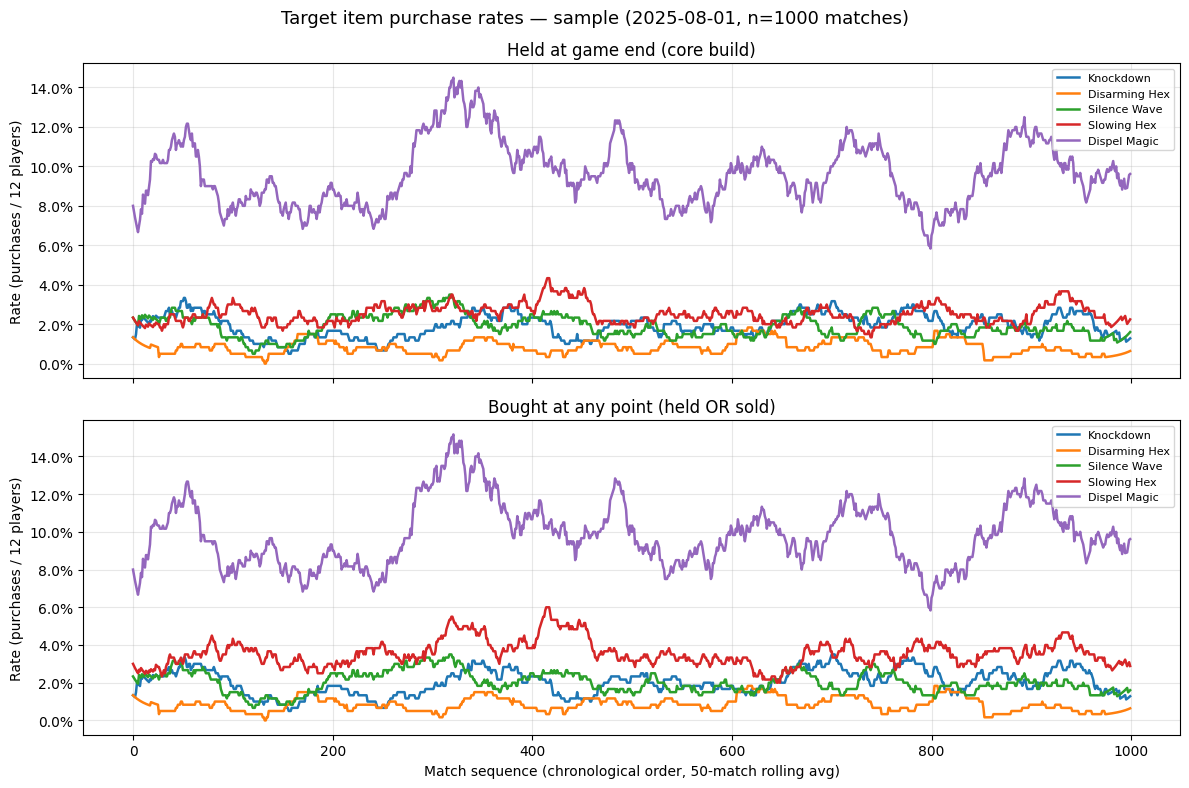

In [38]:
WINDOW = 50  # rolling window in matches; increase to smooth more

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
plot_specs = [
    ('held_rate', 'Held at game end (core build)'),
    ('any_rate',  'Bought at any point (held OR sold)'),
]

for ax, (col, title) in zip(axes, plot_specs):
    for name in TARGET_ITEMS:
        sub = rates_df[rates_df['item'] == name].sort_values('match_seq')
        smoothed = sub[col].rolling(WINDOW, center=True, min_periods=10).mean()
        ax.plot(sub['match_seq'], smoothed, label=name, linewidth=1.8)
    ax.set_ylabel('Rate (purchases / 12 players)')
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

axes[1].set_xlabel(f'Match sequence (chronological order, {WINDOW}-match rolling avg)')
fig.suptitle('Target item purchase rates — sample (2025-08-01, n=1000 matches)', fontsize=13)
plt.tight_layout()
plt.show()

## Sample temporal coverage

Are the 1000 sample matches clustered in time relative to the full dataset?

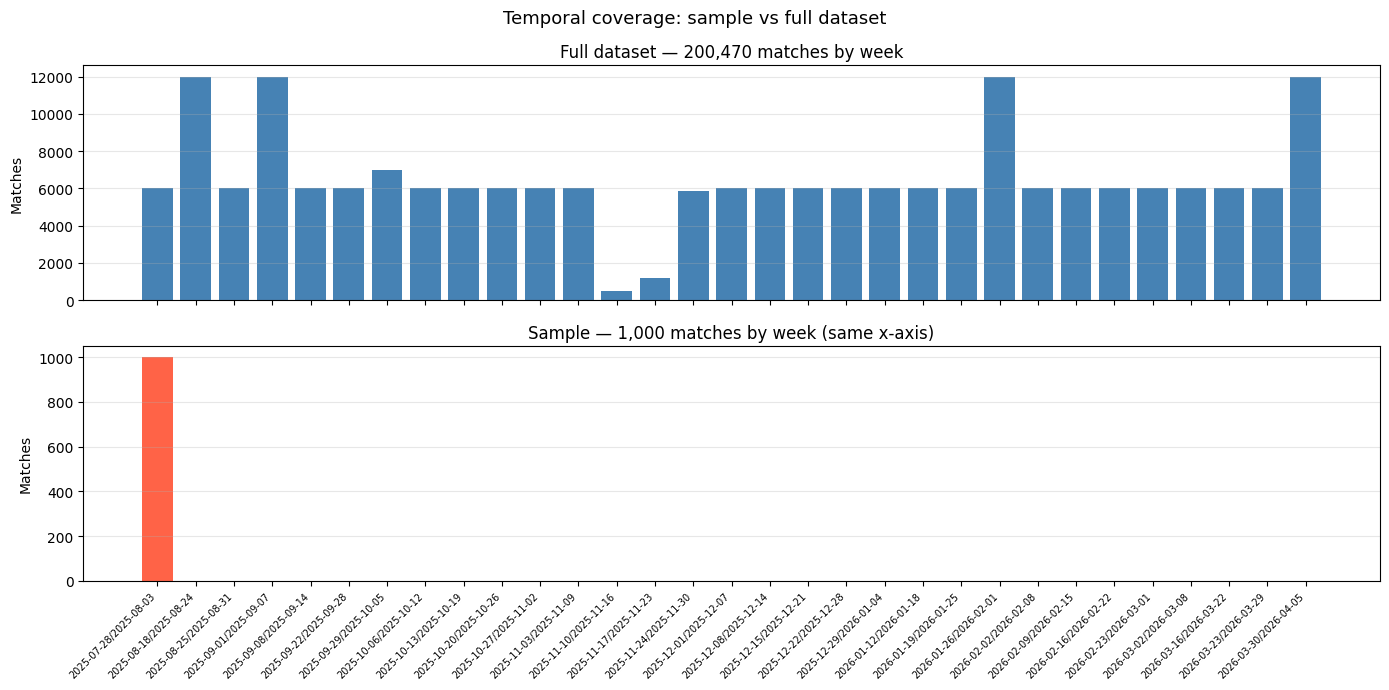

In [39]:
def stream_dates(path):
    """Read only start_time from each record — avoids loading full match data."""
    dates = []
    with open(path) as f:
        for line in f:
            dates.append(json.loads(line)['start_time'][:10])
    return pd.to_datetime(dates).to_series().dt.to_period('W').value_counts().sort_index()

sample_weekly = stream_dates('data/collected_matches_sample.jsonl')
full_weekly   = stream_dates('data/collected_matches.jsonl')

# Align both to the full date index so sample gaps are visible
sample_aligned = sample_weekly.reindex(full_weekly.index, fill_value=0)
x = range(len(full_weekly))
labels = [str(p) for p in full_weekly.index]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].bar(x, full_weekly.values, color='steelblue', width=0.8)
axes[0].set_title(f'Full dataset — {full_weekly.sum():,} matches by week')
axes[0].set_ylabel('Matches')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x, sample_aligned.values, color='tomato', width=0.8)
axes[1].set_title(f'Sample — {sample_aligned.sum():,} matches by week (same x-axis)')
axes[1].set_ylabel('Matches')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Temporal coverage: sample vs full dataset', fontsize=13)
plt.tight_layout()
plt.show()